# Lazy `DatasetCollection` — complete cookbook

A `DatasetCollection` stacks per-file reads into a single 4-D `(T, B, R, C)` lazy `dask.array.Array`. Each timestep
is opened on demand through `CachingFileManager`, so workers never serialise a live `gdal.Dataset` handle — only
the file path crosses the pickle boundary. The time axis is **chunked one timestep per file**, which is exactly
what lets a multi-year stack that would never fit in RAM be reduced timestep-by-timestep, in parallel.

This notebook exercises the **full** collection surface against local test data — a 10-day Rhine runoff series:

1. `DatasetCollection.from_files(...)` — construct without opening every file eagerly.
2. `collection.data` — the 4-D lazy cube, and how it is chunked (including a spatial rechunk).
3. Built-in reductions (`mean` / `sum` / `min` / `max` / `std` / `var`).
4. `collection.groupby(labels)` — per-group reductions (pentads, monthly means, seasonal climatologies).
5. `collection.meta` — the picklable `RasterMeta` snapshot.
6. `collection.to_zarr(store)` — parallel cube write.

## Requirements

```bash
pip install 'pyramids-gis[lazy]'
```

## Setup — imports and the data path

`%matplotlib inline` draws plots inline. We import `numpy` (used to build a per-timestep label array later) and
resolve `DATA` to the repo's `examples/data/` folder, relative to this notebook. All rasters are read locally.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_chunk_grid(arr, title):
    # Draw the dask chunk boundaries over the array's row/column extent (last two axes).
    ny, nx = arr.shape[-2], arr.shape[-1]
    ys, xs = np.cumsum((0,) + arr.chunks[-2]), np.cumsum((0,) + arr.chunks[-1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    for y0, y1 in zip(ys[:-1], ys[1:]):
        for x0, x1 in zip(xs[:-1], xs[1:]):
            ax.add_patch(
                plt.Rectangle(
                    (x0, y0), x1 - x0, y1 - y0, fill=False, ec='crimson', lw=1.4
                )
            )
    ax.set(xlim=(0, nx), ylim=(ny, 0), title=title, xlabel='columns', ylabel='rows')
    ax.set_aspect('equal')
    return fig


DATA = (Path('..') / '..' / '..' / 'examples' / 'data').resolve()
DATA.is_dir()

True

## 1. Build the cube from a time series

`examples/data/geotiff/rhine/` holds ten aligned daily total-runoff (`Qtot`) rasters for 1979-01-01 … 01-10 —
same geobox, one file per day. That is a natural little temporal cube.

In [2]:
# Ten aligned daily rasters: Qtot_1979-01-01.tif .. Qtot_1979-01-10.tif
folder = DATA / 'geotiff' / 'rhine'
files = sorted(folder.glob('Qtot_*.tif'))
[f.name for f in files]

['Qtot_1979-01-01.tif',
 'Qtot_1979-01-02.tif',
 'Qtot_1979-01-03.tif',
 'Qtot_1979-01-04.tif',
 'Qtot_1979-01-05.tif',
 'Qtot_1979-01-06.tif',
 'Qtot_1979-01-07.tif',
 'Qtot_1979-01-08.tif',
 'Qtot_1979-01-09.tif',
 'Qtot_1979-01-10.tif']

`from_files` builds the collection from that file list **without opening every raster** — it reads one template
for the geobox and defers the rest. `time_length`, `rows`, and `columns` come from that lightweight construction:

In [3]:
from pyramids.dataset import DatasetCollection

cube = DatasetCollection.from_files(files)
cube.time_length, cube.rows, cube.columns

(10, 125, 93)

### Peek at one timestep

The cube is lazy, but each timestep is a concrete raster. `iloc(0)` materialises the first slice as a `Dataset`
so we can plot it — a quick visual check before reducing across time.

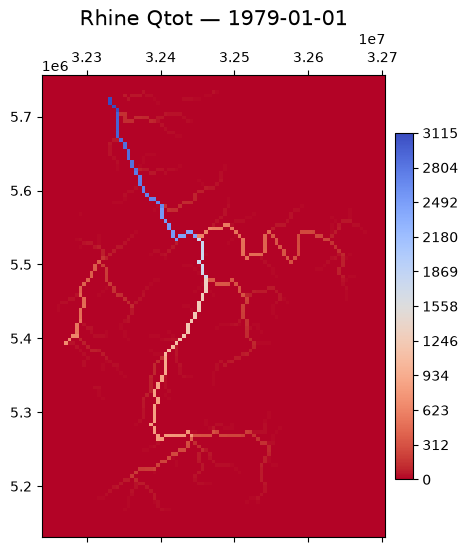

In [4]:
cube.iloc(0).plot(band=0, title="Rhine Qtot — 1979-01-01")

`iloc(0)` pulled a single day back as an eager `Dataset` purely for this visual check — the cube as a whole stays
lazy. Next we look at the 4-D lazy array that backs all ten days at once.

## 2. The lazy 4-D cube — `collection.data`

`collection.data` is a `dask.array.Array` of shape `(T, B, R, C)`. Every per-file read is a `dask.delayed` task
that opens the file via `CachingFileManager`. Displaying it renders dask's summary — the `(10, 1, 125, 93)` shape,
the dtype, the chunk size, and an SVG of the chunk layout. The time axis is cut into **10 chunks (one per day)**;
band, rows and columns are a single chunk each.

In [5]:
cube.data

dask.array<stack, shape=(10, 1, 125, 93), dtype=int32, chunksize=(1, 1, 125, 93), chunktype=numpy.ndarray>

If the HTML repr above doesn't render (it needs a *trusted* notebook), the tiling prints as plain text. The grid
is `(10, 1, 1, 1)` — ten blocks stacked along **time**, one whole file per time-chunk — and `npartitions` is the
total chunk count.

In [6]:
print("backend        :", type(cube.data).__name__, "(dask.array — LAZY)")
print("shape (T,B,R,C):", cube.data.shape, cube.data.dtype)
print("chunk grid     :", cube.data.numblocks, "->", cube.data.npartitions, "chunks")
print("time chunks    :", cube.data.chunks[0], " (one file per timestep)")
print("graph tasks    :", len(cube.data.__dask_graph__()))
print("bytes read     : 0  (nothing computed yet)")

backend        : Array (dask.array — LAZY)
shape (T,B,R,C): (10, 1, 125, 93) int32
chunk grid     : (10, 1, 1, 1) -> 10 chunks
time chunks    : (1, 1, 1, 1, 1, 1, 1, 1, 1, 1)  (one file per timestep)
graph tasks    : 20
bytes read     : 0  (nothing computed yet)


### Rechunking for spatial parallelism

One-file-per-chunk is the default, but you can rechunk to tile **within** each timestep too — useful when a single
scene is itself large. Rechunking to `(1, 1, 64, 64)` splits each day's 125 × 93 grid into a 2 × 2 spatial grid,
so the cube now has `10 × 1 × 2 × 2 = 40` chunks. Displaying it shows the finer layout:

In [7]:
tiled = cube.data.rechunk((1, 1, 64, 64))
tiled.numblocks, tiled.npartitions

((10, 1, 2, 2), 40)

In [8]:
tiled

dask.array<rechunk-merge, shape=(10, 1, 125, 93), dtype=int32, chunksize=(1, 1, 64, 64), chunktype=numpy.ndarray>

Drawn over one timestep's 125 × 93 grid, that spatial rechunk is a 2 × 2 grid of tiles — and there are ten of
these, one per day, for `10 × 4 = 40` chunks in total. Each red box is one dask chunk of independent work. This
image renders even when the HTML repr above does not.

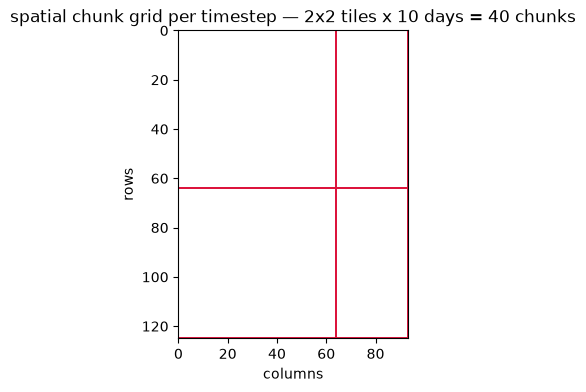

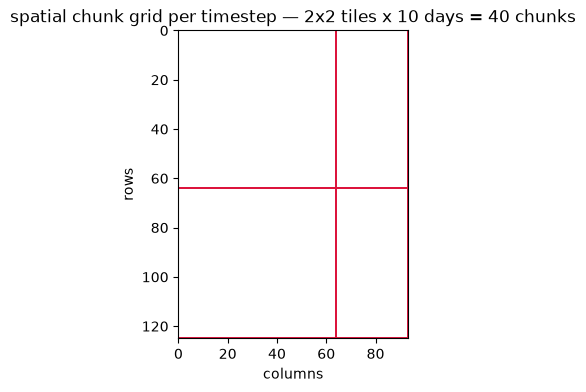

In [9]:
plot_chunk_grid(
    tiled,
    f"spatial chunk grid per timestep — {tiled.numblocks[-2]}x{tiled.numblocks[-1]} tiles "
    f"x {tiled.numblocks[0]} days = {tiled.npartitions} chunks",
)

## 3. Built-in reductions

Six reductions ship directly on the collection so you don't have to write `.data.nanmean(axis=0).compute()`
every time. Each collapses the time axis and returns a `numpy.ndarray` of shape `(B, R, C)` after a single
`.compute()`:

| Reductions | NaN handling | Returns |
|---|---|---|
| `mean` / `sum` / `min` / `max` / `std` / `var` | `skipna=True` skips nodata | `(B, R, C)` ndarray |

In [10]:
time_mean = cube.mean(skipna=True)
time_sum = cube.sum(skipna=True)
type(time_mean).__name__, time_mean.shape

('ndarray', (1, 125, 93))

`mean` returned a concrete `(B, R, C)` array — one `.compute()` collapsed the ten days into a per-pixel average.
The same holds for `std` and `var`; below we sample four reductions and reduce each to a single scalar for a
compact summary:

In [11]:
# std / var are also available
stats = {
    'min': float(np.nanmin(cube.min())),
    'max': float(np.nanmax(cube.max())),
    'mean': float(np.nanmean(cube.mean())),
    'std': float(np.nanmean(cube.std())),
}
stats

{'min': 0.0,
 'max': 3375.0,
 'mean': 22.64785376344086,
 'std': 1.9758473184580472}

## 4. Grouped reductions — `groupby(labels)`

Pass a per-timestep label array and get `{label: array}`. Pyramids builds one lazy dask reduction per group
and evaluates them in a single `dask.compute`, so each source file is read once. Here we split the ten days
into two five-day pentads:

In [12]:
# Per-timestep labels — first pentad vs second pentad.
labels = np.array(['pentad-1'] * 5 + ['pentad-2'] * 5)
grouped = cube.groupby(labels)
group_means = grouped.mean()
sorted(group_means.keys()), group_means['pentad-1'].shape

([np.str_('pentad-1'), np.str_('pentad-2')], (1, 125, 93))

`groupby` returned one array per label. Days `01-01 … 01-05` landed in `pentad-1` and `01-06 … 01-10` in
`pentad-2`, and each value is the per-pixel mean within its group — the pattern behind monthly means or seasonal
climatologies.

## 5. `collection.meta` — the picklable `RasterMeta` snapshot

Every collection caches a frozen `RasterMeta` of the template file's geobox + dtype + nodata. It's the single
place the lazy paths read metadata from — no GDAL opens per call, and the collection pickles cleanly for
`dask.distributed`.

In [13]:
meta = cube.meta
(
    meta.epsg,
    meta.shape,
    meta.cell_size,
    meta.nodata,
    meta.dtype,
)

(4647, (1, 125, 93), 5000.0, (2147483647.0,), 'int32')

Because `meta` is a plain frozen snapshot (no live GDAL handle), it pickles cleanly — the property that lets a
whole collection travel to `dask.distributed` workers intact:

In [14]:
# The snapshot is picklable — ship across dask workers.
import pickle

restored = pickle.loads(pickle.dumps(meta))
restored == meta

True

## 6. Parallel cube write — `collection.to_zarr`

Each dask chunk in `collection.data` lands in an independent Zarr chunk file. The store carries pyramids +
rioxarray attributes (`epsg`, `crs_wkt`, `GeoTransform`, `nodata`, `band_names`, `time_length`, source file list),
so downstream `xr.open_zarr` consumers can reconstruct the geobox without pyramids.

In [15]:
import tempfile

workdir = Path(tempfile.mkdtemp(prefix='pyramids-cube-'))
store = workdir / 'cube.zarr'
cube.to_zarr(store, mode='w')
sorted(p.name for p in store.iterdir())

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

Each dask chunk became an independent Zarr chunk file. The root `zarr.json` carries the pyramids + rioxarray
attributes, so any Zarr/xarray consumer can reconstruct the geobox without pyramids:

In [16]:
# Inspect the metadata — readable by any Zarr/xarray consumer. Zarr v3 keeps
# attributes under the "attributes" key of the store's root zarr.json.
import json

root_attrs = json.loads((store / 'zarr.json').read_text())['attributes']
root_attrs['pyramids_zarr_version'], root_attrs['time_length']

('2', 10)

## Closing notes

- The time axis is chunked one file per timestep; `rechunk(...)` adds spatial tiling when a single scene is large.
- `from_stac(items, asset='B04')` is the STAC variant — same cube, different source. Works on any duck-typed
  STAC-like iterable (pystac.Item, raw JSON dicts, ...); no pyramids extra required.
- `to_kerchunk(path, concat_dim='time')` emits a JSON index for NetCDF/HDF5 cubes; GeoTIFF is tracked as a
  follow-on.
- For a cloud-hosted Sentinel-2 walkthrough, see `dask-lazy-datasets.ipynb` (pairs STAC search with `from_stac`).